# Advanced Artificial Intelligence Task 2: 
## Inference Example

In [5]:
import sys
import os
import cv2
from matplotlib import pyplot as plt
import numpy as np
from safetensors.torch import load_file
import torch
import random
import torch.nn as nn
from torchvision.models import get_model, get_weight
from PIL import Image
from pathlib import Path
import pickle
sys.path.append("..")
sys.path.append(".")
from utils.xai_wrapper import TaskWrapper, swin_reshape_transform
from utils.generate_masks import generate_produce_mask
from utils.grade_produce import grade_colour, grade_colour_generic, grade_proportion, grade_colour_dual
from utils.mtl_model import MultiTaskClassifier
from utils.dataset import ProduceDataset
from experiment_configs import task_2_config_final as experiments
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Select experiment and trained weights path 
# TRAINED_MODEL_PATH = Path(".") / "models" / "best/EX2_SWIN_FINETUNE_44_20260424015207.safetensors"
# EXPERIMENT = experiments.EX2_SWIN_FINETUNE
TRAINED_MODEL_PATH = Path(".") / "models" / "best/EX6a_SWIN_FINETUNE_MTL_20260422201021.safetensors"
EXPERIMENT = experiments.EX6a_SWIN_FINETUNE_MTL
assert EXPERIMENT.display_name.lower() in TRAINED_MODEL_PATH.stem.lower(), \
        (f"Checkpoint '{TRAINED_MODEL_PATH.name}"
         f"doesn't match experiment '{EXPERIMENT.display_name}"
         )
PRODUCE_DATESET_PATH = Path(".") / "data" / "Fruit_And_Vegetable_Diseases_Dataset"
# Type threshold given the limited number of produce types
# Inputs below the threshold will be considered "Uknown"
TYPE_CONFIDENCE_THRESHOLD = 50


# Load empty model architecture (without pretrained weights)
# Build the same MTL wrapper used during training
PRETRAINED_MODEL = get_model(EXPERIMENT.architecture, weights=None)
produce_dataset = ProduceDataset(dataset_root_dir=PRODUCE_DATESET_PATH, 
                                 transform=None)

if EXPERIMENT.is_mtl:
    # MTL: instantiate custom MTL with auxillary produce type objective
     # Need num_types to match training - get from dataset
    model = MultiTaskClassifier(PRETRAINED_MODEL, 
                                num_produce_classes=produce_dataset.num_produce_types)
else:
    # STL: replace the final classifier for binary health classification
    head_attr = "classifier" if hasattr(PRETRAINED_MODEL, "classifier") else "head"
    head = getattr(PRETRAINED_MODEL, head_attr)
    if isinstance(head, nn.Sequential):
        head[-1] = nn.Linear(head[-1].in_features, 2)
    # Swin exposes .head (single Linear).
    elif isinstance(head, nn.Linear):
        setattr(PRETRAINED_MODEL, head_attr, nn.Linear(head.in_features, 2))
    else:
        raise ValueError(f"Unsupported STL classification_head: {type(head).__name__}")
    model = PRETRAINED_MODEL
    
# Load trained weights into the MTL wrapper
if os.path.splitext(TRAINED_MODEL_PATH)[1] == ".pth":
    model.load_state_dict(torch.load(TRAINED_MODEL_PATH, weights_only=True))
else: # Load as safetensor
    state_dict = load_file(TRAINED_MODEL_PATH)
    model.load_state_dict(state_dict)

# Send to device and set model to eval mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Get transforms for inference input
pretrained_weights = get_weight(EXPERIMENT.weight_string)
auto_transforms = pretrained_weights.transforms()

# Define the target classes
health_names = ['Healthy', 'Rotten']
type_names = produce_dataset.produce_type_names


[MTL] Detected head attr: '.head'  arch=SwinTransformer
[MTL] Original head:
Linear(in_features=768, out_features=1000, bias=True)
[MTL] Backbone+neck output shape: (1, 768)  (expected (1, 768))


In [16]:

def classify_produce(image_path):
    """
    Classify a single image of produce.
    Returns the predicted health label and confidence
    If the model is MTL, fruit type and type confidence is aditionally returned.
    """
    image = Image.open(image_path).convert("RGBA").convert("RGB")
    input_tensor = auto_transforms(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        if EXPERIMENT.is_mtl:
            health_output, type_output = model(input_tensor)
        else:
            health_output = model(input_tensor)
        
        # Health prediction
        health_probs = torch.nn.functional.softmax(health_output, dim=1)[0]
        health_pred_id = health_probs.argmax().item()
        health_confidence = health_probs[health_pred_id].item() * 100
        
    health_label = health_names[health_pred_id]
    print(f"Health: {health_label} ({health_confidence:.1f}%)")

    result = {
    "health_label": health_label,
    "health_confidence": health_confidence,
    "health_pred_id": health_pred_id,   # For Grad-CAM targets
    "input_tensor": input_tensor,       # For Grad-CAM targets
    "fruit_type": None,
    "type_confidence": None,
    "known_type": None,
    "type_pred_id": None
    }

    if EXPERIMENT.is_mtl:
        # Type prediction for gradcam
        type_probs = torch.nn.functional.softmax(type_output, dim=1)[0]
        type_pred_id = type_probs.argmax().item()
        type_confidence = type_probs[type_pred_id].item() * 100

        fruit_type = type_names[type_pred_id]
        known = type_confidence >= TYPE_CONFIDENCE_THRESHOLD
        result["fruit_type"] = fruit_type if known else "unknown"
        result["type_confidence"] = type_confidence
        result["known_type"] = known
        
        print((f"Type:   {result['fruit_type']} ({type_confidence:.1f}%)" 
               f"{'' if known else f'({fruit_type} - {TYPE_CONFIDENCE_THRESHOLD-type_confidence:.1f} below threshold)'}"))
        
    return result

def grade_produce(image_path, healthy_colour_refs=None, rotten_colour_references=None,
                colour_distribution=None, grade_colour_vs_ref = False, preview_img=True,
                composite_result=True, softmax_g=0,cam=None) -> dict:
    """
    Determine grading based on ripeness, colour and proportion.
    Ripeness    - Softmax prediction confidence from classify_produce()
    Colour      - STL/fallback: Score of saturation/vividty (OpenCV) 
                - MTL: HSV histogram similarity vs known produce healthy reference (OpenCV) 
    Proportion  - Contour solidity (OpenCV)
    """
    mask = generate_produce_mask(str(image_path), method="rembg")
    classification = classify_produce(image_path)


    # Ripeness: use confidence from ML classification
    label = classification["health_label"]
    fruit_type = classification["fruit_type"]

    # If healthy, confidence = ripeness; rotten, invert.
    ripeness_score = (
        classification["health_confidence"]
        if label == "Healthy"
        else 100 - classification["health_confidence"]
    )

    # Always compute generic score to show as baseline

    generic_score, vibrancy = grade_colour_generic(
        image_path, colour_distribution, mask=mask)
    if classification.get("known_type") and rotten_colour_references and grade_colour_vs_ref:
        dual_score, summary_str = grade_colour_dual(image_path, fruit_type,
                                     healthy_colour_refs, rotten_colour_references,
                                       mask=mask, gamma=softmax_g)
        colour_score = max(dual_score, generic_score)
    elif classification.get("known_type") and healthy_colour_refs and grade_colour_vs_ref:
        # Known type => gauge colour score from known standard
        colour_score, summary_str  = grade_colour(image_path, fruit_type,
                                     healthy_colour_refs, mask=mask), ""

    else:
        # Unknown/STL => fall back to generic score
        colour_score, summary_str  = generic_score, ""
    print(summary_str)
    proportion_score = grade_proportion(image_path, mask=mask)
    
    scores = {
        "ripeness": ripeness_score,
        "colour": colour_score,
        "size": proportion_score,
    }

    # Grade thresholds: must meet ALL minimums for that grade

    THRESHOLDS = [
        ("A", {"colour": 85, "size": 90, "ripeness": 80}),
        ("B", {"colour": 75, "size": 80, "ripeness": 70}),
        ("C", {"colour": 65, "size": 70, "ripeness": 60}),
    ]
    COMPOSITE_THRESHOLDS = [
        (grade, sum(criteria.values()) / len(criteria))
        for grade, criteria in THRESHOLDS
    ]
    composite_score = 0

    if composite_result:
        composite_score = (ripeness_score + colour_score + proportion_score) / 3
        grade = "D"
        for grade_name, avg_threshold in COMPOSITE_THRESHOLDS:
            if composite_score >= avg_threshold:
                grade = grade_name
                break
    else:
        grade = "D"  # default if no threshold met and not rotten
        for threshold_grade, minimums in THRESHOLDS:
            if all(scores[key] >= minimums[key] for key in minimums):
                grade = threshold_grade
                break

    if label == "Rotten": # still compute scores
        grade = "Rejected"

    used_ref = classification.get("known_type") and healthy_colour_refs and grade_colour_vs_ref
    if used_ref:
        colour_type = "Hist similarity:"
        colour_detail = f"(: {int(generic_score)}%)"
    else:
        # colour_detail = f"(Vibrancy percentile: {int(generic_score)}%)"
        colour_type="Type Agnostic"
        colour_detail = ''
    colour_label = f'Colour ({colour_type}):'
    grade_str = f"{'Composite grade:':<17}{composite_score:.1f}" if composite_result else f"{'Grade:':<17}"
    explanation = (
        f"{grade_str} ({grade})\n" 
        f"{'Ripeness:':<17}{int(ripeness_score)}% (Healthy confidence)\n"
        f"{colour_label :<17}{int(colour_score)}% {colour_detail}\n"
        f"{'Proportion:':<17}{int(proportion_score)}% (contour)"
    )

    if preview_img:
        image_tensor = classification["input_tensor"]
        predicted_health_idx = classification["health_pred_id"]
        # Generate grad_cam
        targets = [ClassifierOutputTarget(predicted_health_idx)]
        grayscale_cam = cam(input_tensor=image_tensor, targets=targets)[0, :]
        
        # Prepare the original image for visualization (scale to 0-1)
        mean = torch.tensor([0.485, 0.456, 0.406], device=image_tensor.device).view(1, 3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225], device=image_tensor.device).view(1, 3, 1, 1)
        denorm = (image_tensor * std + mean).clamp(0, 1)
        rgb_img = denorm[0].detach().cpu().permute(1, 2, 0).numpy().astype(np.float32)
                        
        # Overlay the heatmap on the image
        cam_visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        

        img = Image.open(image_path).convert('RGB')
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].imshow(img)
        axes[0].set_title("Original")
        axes[0].axis("off")
        
        # Resize mask to match image if needed
        mask_display = cv2.resize(
            mask, (img.width, img.height), 
            interpolation=cv2.INTER_NEAREST) if mask.shape[:2] != (img.height, img.width) else mask
        axes[1].imshow(mask_display, cmap="gray")
        axes[1].set_title("Segmentation Mask")
        axes[1].axis("off")

        axes[2].imshow(cam_visualization)
        plt.title(f"Grad-CAM (Health: {health_names[predicted_health_idx]})")
        axes[2].axis("off")
        plt.tight_layout()

        plt.figtext(0.5, 0.02, f"{explanation}\n{summary_str}" , ha="center", va="top", 
                    fontsize=12, family="monospace", 
                    bbox={"facecolor":"white", "alpha":0.8, "pad":5})
        # plt.figtext(0.5, 0.02, summary_str, ha="center", va="top", 
        #             fontsize=12, family="monospace", 
        #             bbox={"facecolor":"white", "alpha":0.8, "pad":5})
        plt.show()
    return {
        "prediction": label,
        "fruit_type": fruit_type,
        "ripeness_score": ripeness_score,
        "color_score": colour_score,
        "generic_colour_score": generic_score,
        "proportion_score": proportion_score,
        "overall_grade": grade,
        "explanation": explanation,
    }

cam_wrapper = TaskWrapper(model, target_task='health').eval()
# target_layers = [cam_wrapper.base_model.backbone.features[-1]]
target_layers = [cam_wrapper.base_model.backbone.norm]
cam = GradCAM(model=cam_wrapper, 
              target_layers=target_layers, 
              reshape_transform=swin_reshape_transform)

print(type(cam_wrapper.base_model))                  # should be MultiTaskClassifier
print(hasattr(cam_wrapper.base_model, 'backbone'))   # True if the attribute exists
print(type(cam_wrapper.base_model.backbone))    

<class 'utils.mtl_model.MultiTaskClassifier'>
True
<class 'torchvision.models.swin_transformer.SwinTransformer'>


Health: Rotten (100.0%)
Type:   guava (98.0%)

Health: Rotten (100.0%)
Type:   guava (98.0%)

DUAL COLOUR GRADING: GUAVA
--------------------------------------------------
1. Raw Bhattacharyya Distances (Lower is better):
d_healthy  = 0.8616
d_rotten   = 0.6022

2. Exponential Weighting (gamma = 5):
Formula:   w = exp(-gamma * distance)
w_healthy  = exp(-5    * 0.8616) = 0.0135
w_rotten   = exp(-5    * 0.6022) = 0.0492

3. Final Score Calculation (Healthy Weight Ratio):
Formula:   (w_healthy / (w_healthy + w_rotten)) * 100
           (0.0135 / (0.0135 + 0.0492)) * 100
           (0.0135 / 0.0627) * 100
--------------------
FINAL COLOUR GRADE: 21.5% (Unweighted: 41.139292 )

d_H:0.862 | d_R:0.602
w_H:0.013 | w_R:0.049 (g=5)
Score:21.5% (Raw:41.1%)


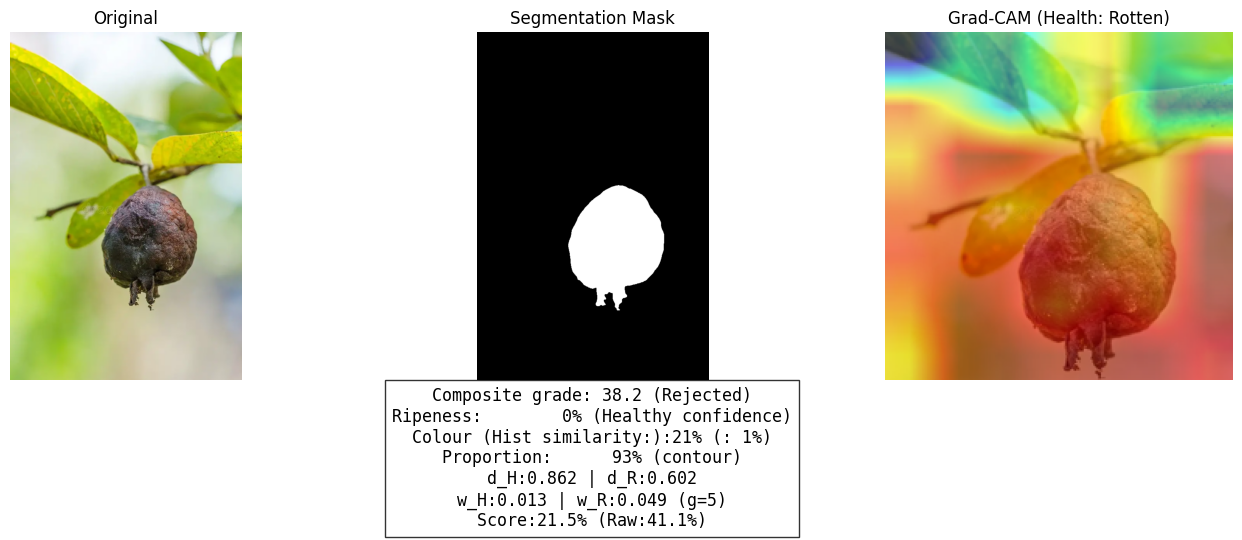

data/golden_dataset/Guava__Rotten/rotten-guava-fruit-tree-garden-61884554.webp

Composite grade: 38.2 (Rejected)
Ripeness:        0% (Healthy confidence)
Colour (Hist similarity:):21% (: 1%)
Proportion:      93% (contour)


In [19]:
ood_test = False #overrides healthy and correct
show_healthy = False # Healthy predicitons only
show_correct = False # Find correct prediction

# Load references once
ref_path = Path(".") / "data" / "colour_references_rembg.pkl"
dist_path = Path(".") / "data" / "generic_colour_distribution.pkl"
rotten_ref_path = Path(".") / "data" /"colour_references_rembg_rotten.pkl"
with open(ref_path, "rb") as f:
    healthy_colour_refs = {k.lower(): v for k, v in pickle.load(f).items()}
with open(dist_path, "rb") as f:
    colour_distribution = {k.lower(): v for k, v in pickle.load(f).items()}

with open(rotten_ref_path, "rb") as f:
    rotten_refs = {k.lower(): v for k, v in pickle.load(f).items()}

while True:
    if ood_test:
        ood_test_image_dir = Path(".") / "data" / "test_data"
        images = [f for f in os.listdir(ood_test_image_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
        rdm_test_image = ood_test_image_dir / random.choice(images)
    else:
        test_img_dir = Path(".") / "data" / "golden_dataset"
        rdm_class_dir = test_img_dir / random.choice(os.listdir(test_img_dir))
        rdm_test_image = rdm_class_dir / random.choice(os.listdir(rdm_class_dir))

    result = grade_produce(rdm_test_image, healthy_colour_refs, rotten_refs, colour_distribution,
                           preview_img=False, composite_result=True, softmax_g=5,cam=cam)

    type_ok = not show_correct or result.get("fruit_type") != "unknown"
    health_ok = not show_healthy or result.get("prediction") != "Rotten"

    if ood_test or (type_ok and health_ok):
        result = grade_produce(rdm_test_image, healthy_colour_refs, rotten_refs, colour_distribution, 
                               grade_colour_vs_ref=True, preview_img=True, composite_result=True, softmax_g=5,cam=cam )
        break

print(rdm_test_image)
print("\n" + result['explanation'])